In [35]:
# ============================================
# DATA UNDERSTANDING PHASE
# ============================================
# Objective:
# Explore the dataset to understand its structure,
# identify key variables, detect issues (missing values,
# outliers), and uncover patterns related to diabetes risk.

In [36]:
!pip install matplotlib

In [37]:
!pip install pandas

In [38]:
!pip install numpy

In [39]:
!pip install seaborn

In [40]:
# Import the necessary libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from IPython.display import display 
from sklearn.preprocessing import StandardScaler
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


# Set default figure size for better readability
plt.rcParams["figure.figsize"] = (10,6)


In [41]:
df = pd.read_csv("../BC_Analytics/Diabetes_and_LifeStyle_Dataset_.csv")
# Load the dataset into a pandas DataFrame and then only display a preview of the records

df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [42]:
df.shape
# Check the number of rows and columns in the dataset

(97297, 31)

In [43]:
df.info()
# Display information about data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

In [44]:
df.describe()
# Generate a summary statistic for numerical features

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [45]:
df.isnull().sum()
# Check for missing values in each column

Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


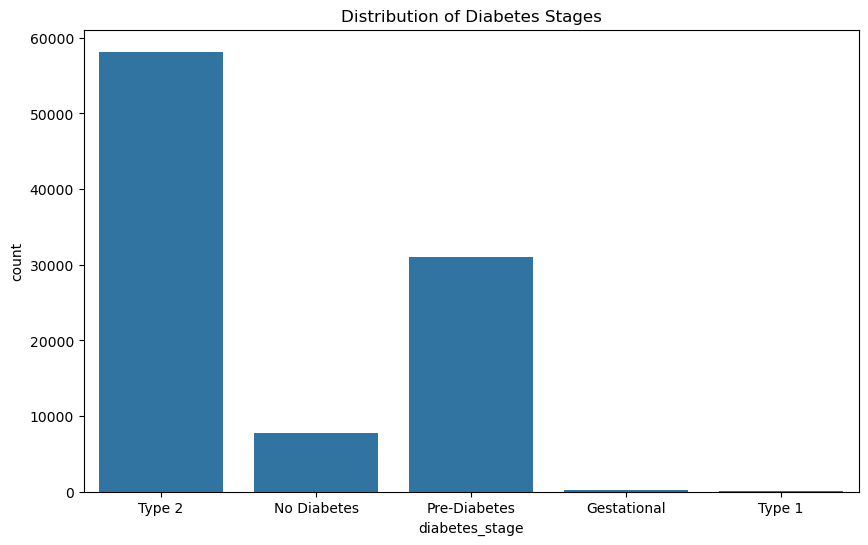

In [46]:
df['diabetes_stage'].value_counts()

sns.countplot(x='diabetes_stage', data=df)
plt.title("Distribution of Diabetes Stages")
plt.show()
# First counts how many records fall into each diabetes stage, then visualizes the distribution of diabetes stages


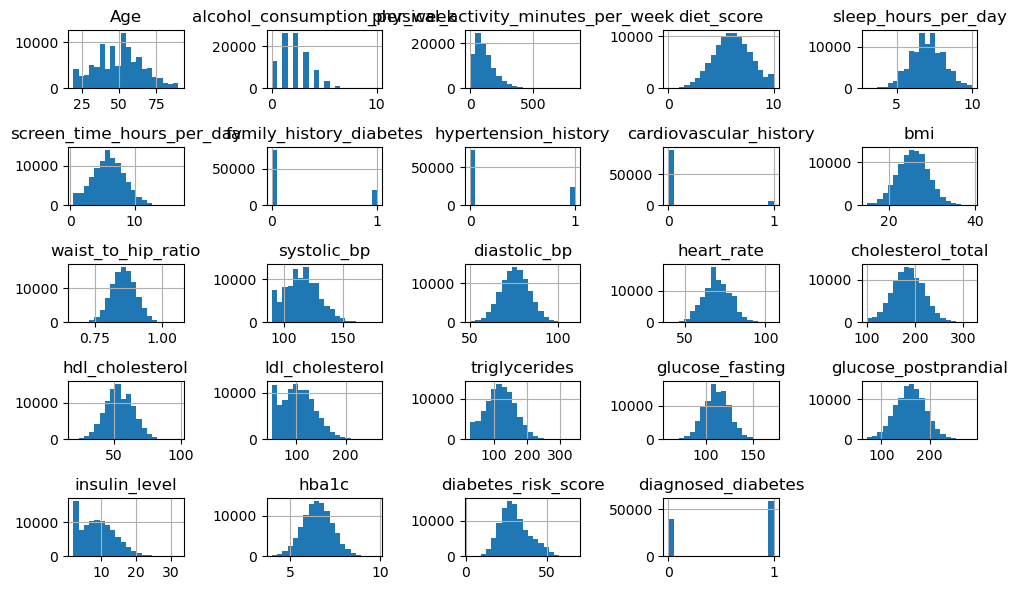

In [47]:
df.hist(bins=20)
plt.tight_layout()
plt.show()
# Plot histograms for all numerical features to understand distributions

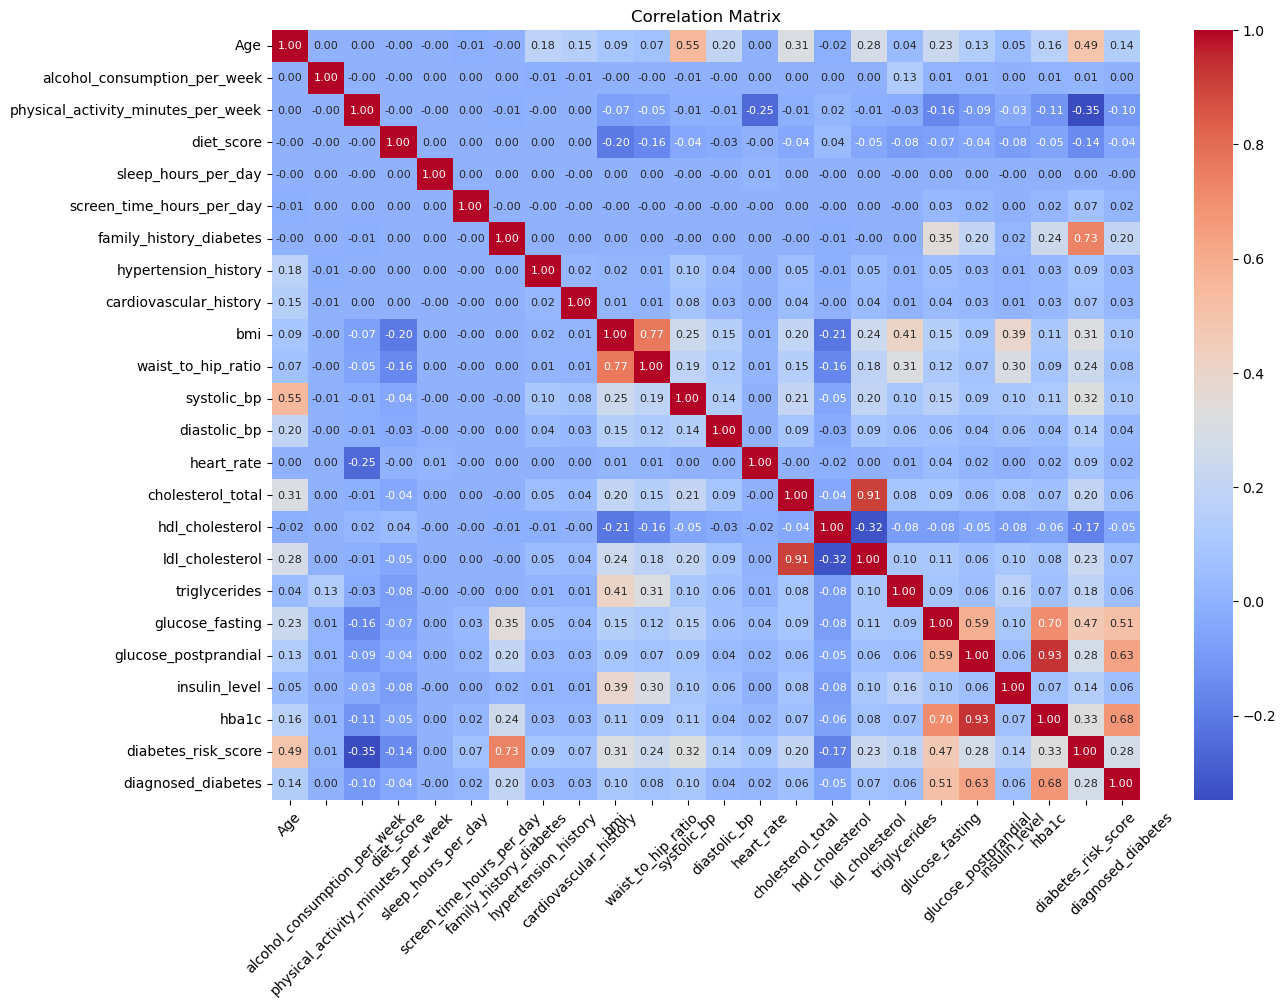

In [48]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))  # BIGGER FIGURE
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size":8})
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()
# First computes the correlation matrix for numerical variables, then visualizes correlations using a heatmap


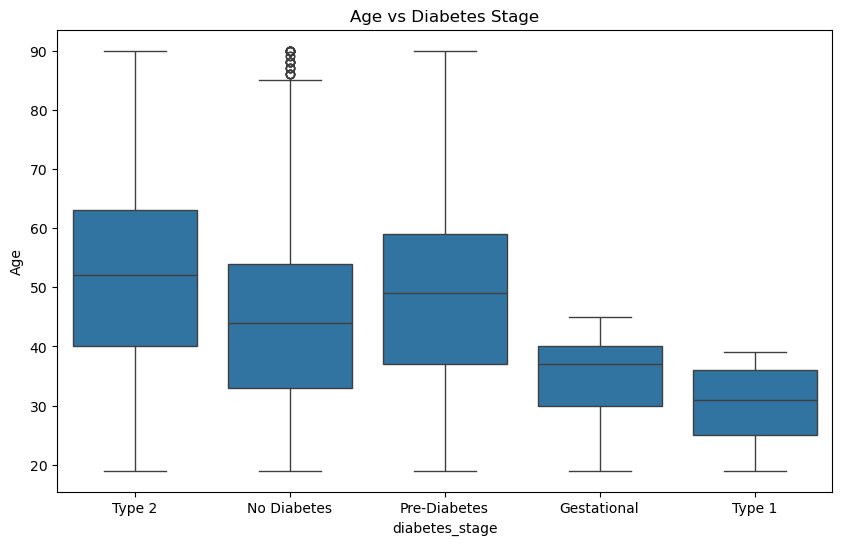

In [49]:
sns.boxplot(x='diabetes_stage', y='Age', data=df)
plt.title("Age vs Diabetes Stage")
plt.show()
# Compare Age distribution across diabetes stages

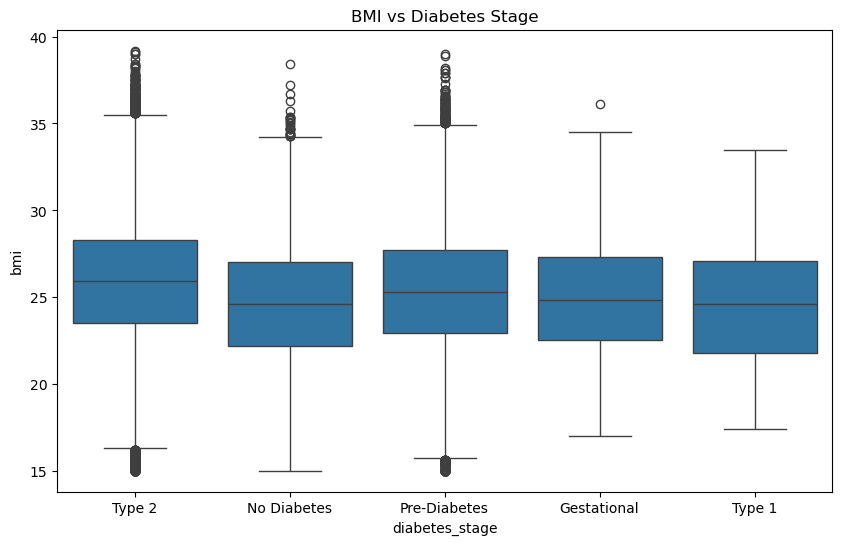

In [50]:
sns.boxplot(x='diabetes_stage', y='bmi', data=df)
plt.title("BMI vs Diabetes Stage")
plt.show()
# Compare BMI distribution across diabetes stages

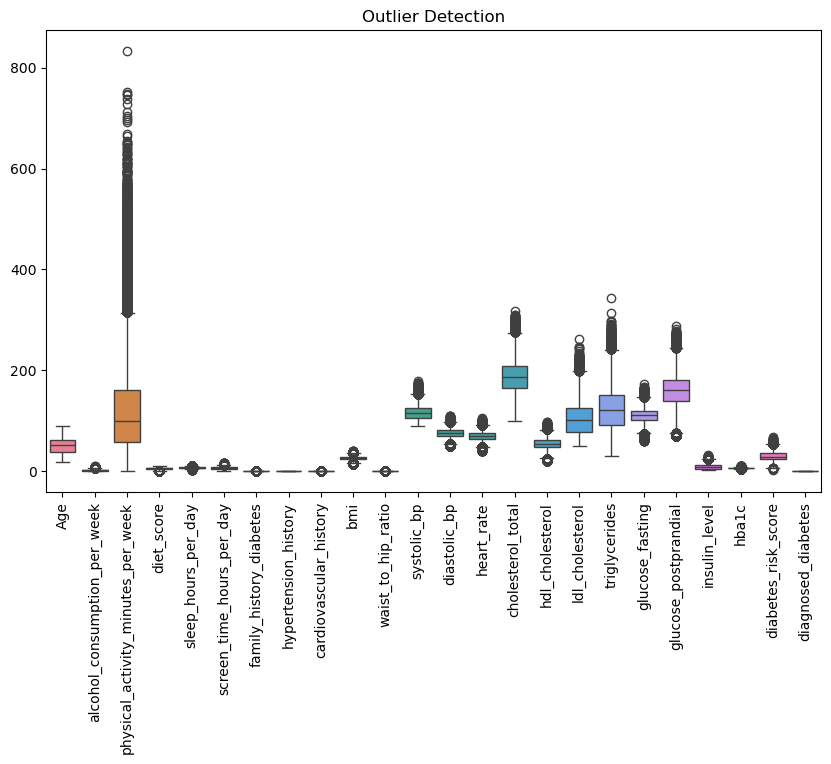

In [51]:
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()
# Detect outliers in numerical features using boxplots

In [52]:
# KEY INSIGHTS
# ============================================
# - The dataset contains multiple health and lifestyle features
# - The target variable (diabetes_stage) shows how patients are distributed across risk levels
# - Certain features, such as BMI and age, appear to vary across different diabetes stages
# - Outliers are present in some numerical variables
# - These findings will guide data preparation and modeling in the next phase



In [53]:
# ============================================
# DATA Preprocessing PHASE
# ============================================
# Objective:
# Data Cleaning 
# Encoding 
# Handle outliers

In [54]:
#check for duplicate values
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes]
Index: []

[0 rows x 31 columns]


In [55]:
#Data Reduction - removing unecessary columns for modeling(Feature Selection) for predicting diabetes stage 

X = df.drop("diabetes_stage", axis=1)
y = df["diabetes_stage"]

#Convert catergorial values 
X = pd.get_dummies(X)

model = RandomForestClassifier()
model.fit(X,y)

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                               feature  importance
23                  diagnosed_diabetes    0.408825
21                               hba1c    0.303838
19                glucose_postprandial    0.099788
18                     glucose_fasting    0.099707
22                 diabetes_risk_score    0.010936
2   physical_activity_minutes_per_week    0.005257
0                                  Age    0.004803
6              family_history_diabetes    0.004435
9                                  bmi    0.004322
17                       triglycerides    0.004041
5            screen_time_hours_per_day    0.003909
20                       insulin_level    0.003885
14                   cholesterol_total    0.003852
11                         systolic_bp    0.003828
3                           diet_score    0.003712
4                  sleep_hours_per_day    0.003647
16                     ldl_cholesterol    0.003614
15                     hdl_cholesterol    0.003531
13                          hea

In [56]:
#diagnosed_diabetes has a 0.424851 importance which makes it unrelaistic and there's a presence of data leakage.
# This makes the model look very accurate during training, but it’s misleading because it’s cheating
#it’s learning from data that won’t be available in real-world use. As a result, the model won’t perform as well on new, unseen data. 
#In simple terms, data leakage is like giving a student the answers while testing them ,they score high but haven’t truly learned anything useful.

In [57]:
#Remove data leakage 
X = df.drop([ "diabetes_stage", "diagnosed_diabetes"], axis=1)
y = df["diabetes_stage"]

X = pd.get_dummies(X)
model = RandomForestClassifier()
model.fit(X,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


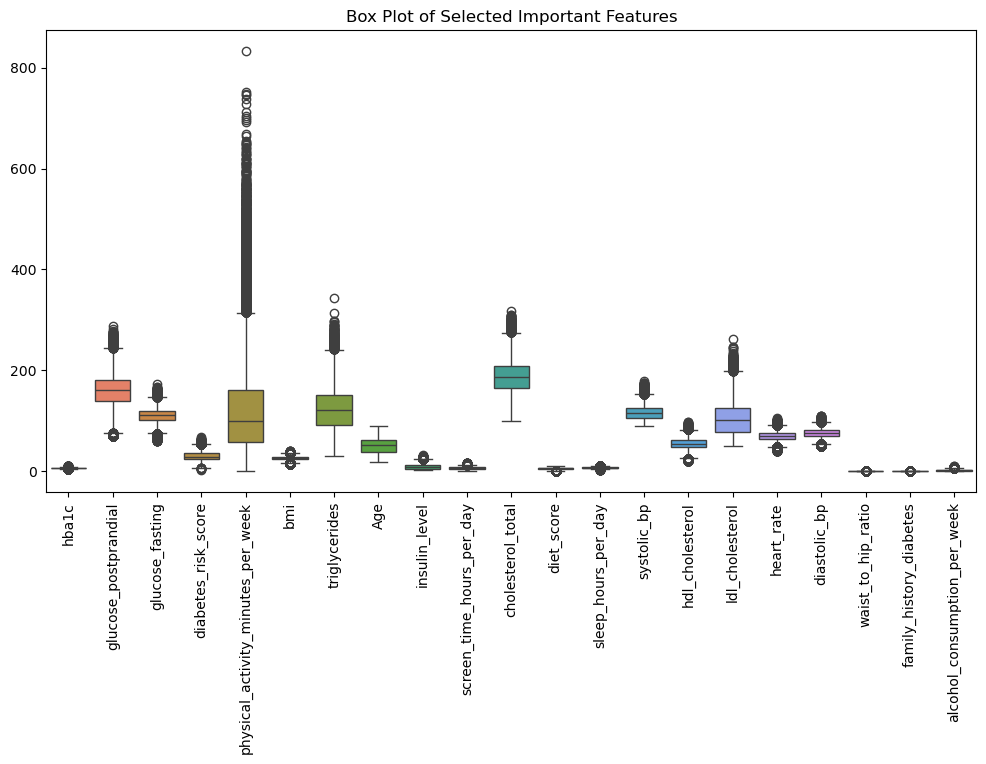

In [58]:
#which feature matter for prediction ?
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

important_features = feature_importance_df[
    feature_importance_df["importance"] > 0.005
]

selected_columns = important_features["feature"]
X_selected = X[selected_columns]

#plot boxplot to identify outliers 

plt.figure(figsize=(12,6))
sns.boxplot(data=X_selected)
plt.xticks(rotation=90)
plt.title("Box Plot of Selected Important Features")
plt.show()

In [59]:
X[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
hba1c,97297.0,6.520338,0.813710,4.00,5.97,6.52,7.07,9.80
glucose_postprandial,97297.0,160.014348,30.938915,70.00,139.00,160.00,181.00,287.00
glucose_fasting,97297.0,111.121792,13.590382,60.00,102.00,111.00,120.00,172.00
diabetes_risk_score,97297.0,30.222027,9.065063,2.70,23.80,29.00,35.60,67.20
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20
triglycerides,97297.0,121.466407,43.393422,30.00,91.00,121.00,151.00,344.00
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
insulin_level,97297.0,9.063591,4.956342,2.00,5.09,8.79,12.45,32.22
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80


In [60]:
# compute skewness automatically
skewness = X_selected.skew().sort_values(ascending=False)

print(skewness)

physical_activity_minutes_per_week    1.390451
family_history_diabetes               1.354286
alcohol_consumption_per_week          0.702080
diabetes_risk_score                   0.513594
insulin_level                         0.423257
ldl_cholesterol                       0.319729
systolic_bp                           0.219172
Age                                   0.129394
triglycerides                         0.104238
screen_time_hours_per_day             0.083622
glucose_fasting                       0.045812
cholesterol_total                     0.032767
hba1c                                 0.030311
glucose_postprandial                  0.025540
diastolic_bp                          0.007730
bmi                                   0.005636
waist_to_hip_ratio                    0.003370
hdl_cholesterol                      -0.003319
sleep_hours_per_day                  -0.010653
heart_rate                           -0.018223
diet_score                           -0.071064
dtype: float6

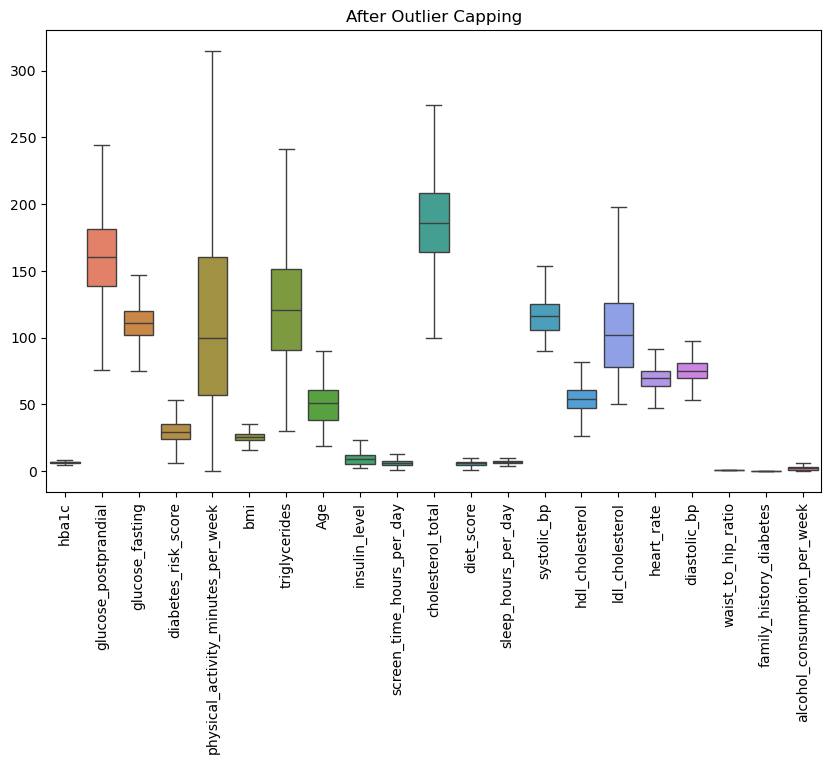

In [61]:
#Capping Technique

Q1 = X_selected.quantile(0.25)
Q3 = X_selected.quantile(0.75)
IQR = Q3 - Q1

X_capped = X_selected.copy()

for col in X_selected.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]

    X_capped[col] = X_selected[col].clip(lower, upper)
    
sns.boxplot(data=X_capped)
plt.xticks(rotation=90)
plt.title("After Outlier Capping")
plt.show()

In [62]:


#Boxplot defines outliers as values outside IQR bounds
#After capping:
#all values are inside bounds
#so boxplot shows no outliers
#This shows that the dataset is fairly clean most skewness was from categorical variables,numeric features were well-behaved/controlled

#How many values were modified per column
(X_selected != X_capped).sum()


hba1c                                   599
glucose_postprandial                    617
glucose_fasting                         722
diabetes_risk_score                     889
physical_activity_minutes_per_week     3115
bmi                                     729
triglycerides                           291
Age                                       0
insulin_level                           322
screen_time_hours_per_day               302
cholesterol_total                       296
diet_score                              325
sleep_hours_per_day                     870
systolic_bp                             517
hdl_cholesterol                         555
ldl_cholesterol                         340
heart_rate                              836
diastolic_bp                            717
waist_to_hip_ratio                      265
family_history_diabetes               21372
alcohol_consumption_per_week            443
dtype: int64

In [63]:
X_selected.corr()

,hba1c,glucose_postprandial,glucose_fasting,diabetes_risk_score,physical_activity_minutes_per_week,bmi,triglycerides,Age,insulin_level,screen_time_hours_per_day,...,diet_score,sleep_hours_per_day,systolic_bp,hdl_cholesterol,ldl_cholesterol,heart_rate,diastolic_bp,waist_to_hip_ratio,family_history_diabetes,alcohol_consumption_per_week
hba1c,1.000000,0.933174,0.700328,0.330464,-0.112289,0.110229,0.066224,0.159293,0.072736,0.024040,...,-0.054412,0.001577,0.110884,-0.059348,0.075256,0.024486,0.044595,0.087803,0.242931,0.006455
glucose_postprandial,0.933174,1.000000,0.589210,0.277470,-0.093567,0.092516,0.057278,0.132566,0.060987,0.020621,...,-0.044979,0.000856,0.093678,-0.049861,0.064291,0.018603,0.036734,0.073922,0.204973,0.005257
glucose_fasting,0.700328,0.589210,1.000000,0.470278,-0.161445,0.151253,0.087473,0.231403,0.102840,0.033387,...,-0.072204,0.001556,0.154084,-0.081652,0.105112,0.043440,0.064219,0.117856,0.345316,0.007457
diabetes_risk_score,0.330464,0.277470,0.470278,1.000000,-0.347707,0.314368,0.181422,0.494831,0.142905,0.070170,...,-0.144465,0.003162,0.323446,-0.174426,0.228091,0.091734,0.135540,0.242037,0.733182,0.010793
physical_activity_minutes_per_week,-0.112289,-0.093567,-0.161445,-0.347707,1.000000,-0.071631,-0.026237,0.003020,-0.034125,0.001103,...,-0.002773,-0.004995,-0.008170,0.018163,-0.014330,-0.253699,-0.008613,-0.053595,-0.006775,-0.002082
bmi,0.110229,0.092516,0.151253,0.314368,-0.071631,1.000000,0.405606,0.093728,0.392163,-0.003568,...,-0.201331,0.000546,0.246302,-0.211943,0.238953,0.014459,0.150671,0.766123,0.000439,-0.002852
triglycerides,0.066224,0.057278,0.087473,0.181422,-0.026237,0.405606,1.000000,0.040028,0.163816,-0.004595,...,-0.080170,-0.003513,0.104155,-0.084232,0.098719,0.009281,0.061700,0.311000,0.003885,0.126534
Age,0.159293,0.132566,0.231403,0.494831,0.003020,0.093728,0.040028,1.000000,0.045420,-0.006167,...,-0.003175,-0.003505,0.547095,-0.015338,0.281130,0.000149,0.196525,0.070225,-0.002675,0.000774
insulin_level,0.072736,0.060987,0.102840,0.142905,-0.034125,0.392163,0.163816,0.045420,1.000000,0.002066,...,-0.080781,-0.000992,0.096819,-0.083107,0.096097,0.002173,0.060726,0.302888,0.017002,0.001075
screen_time_hours_per_day,0.024040,0.020621,0.033387,0.070170,0.001103,-0.003568,-0.004595,-0.006167,0.002066,1.000000,...,0.003059,0.004599,-0.002932,-0.001518,0.001345,-0.000146,-0.000349,-0.003939,-0.002001,0.001794


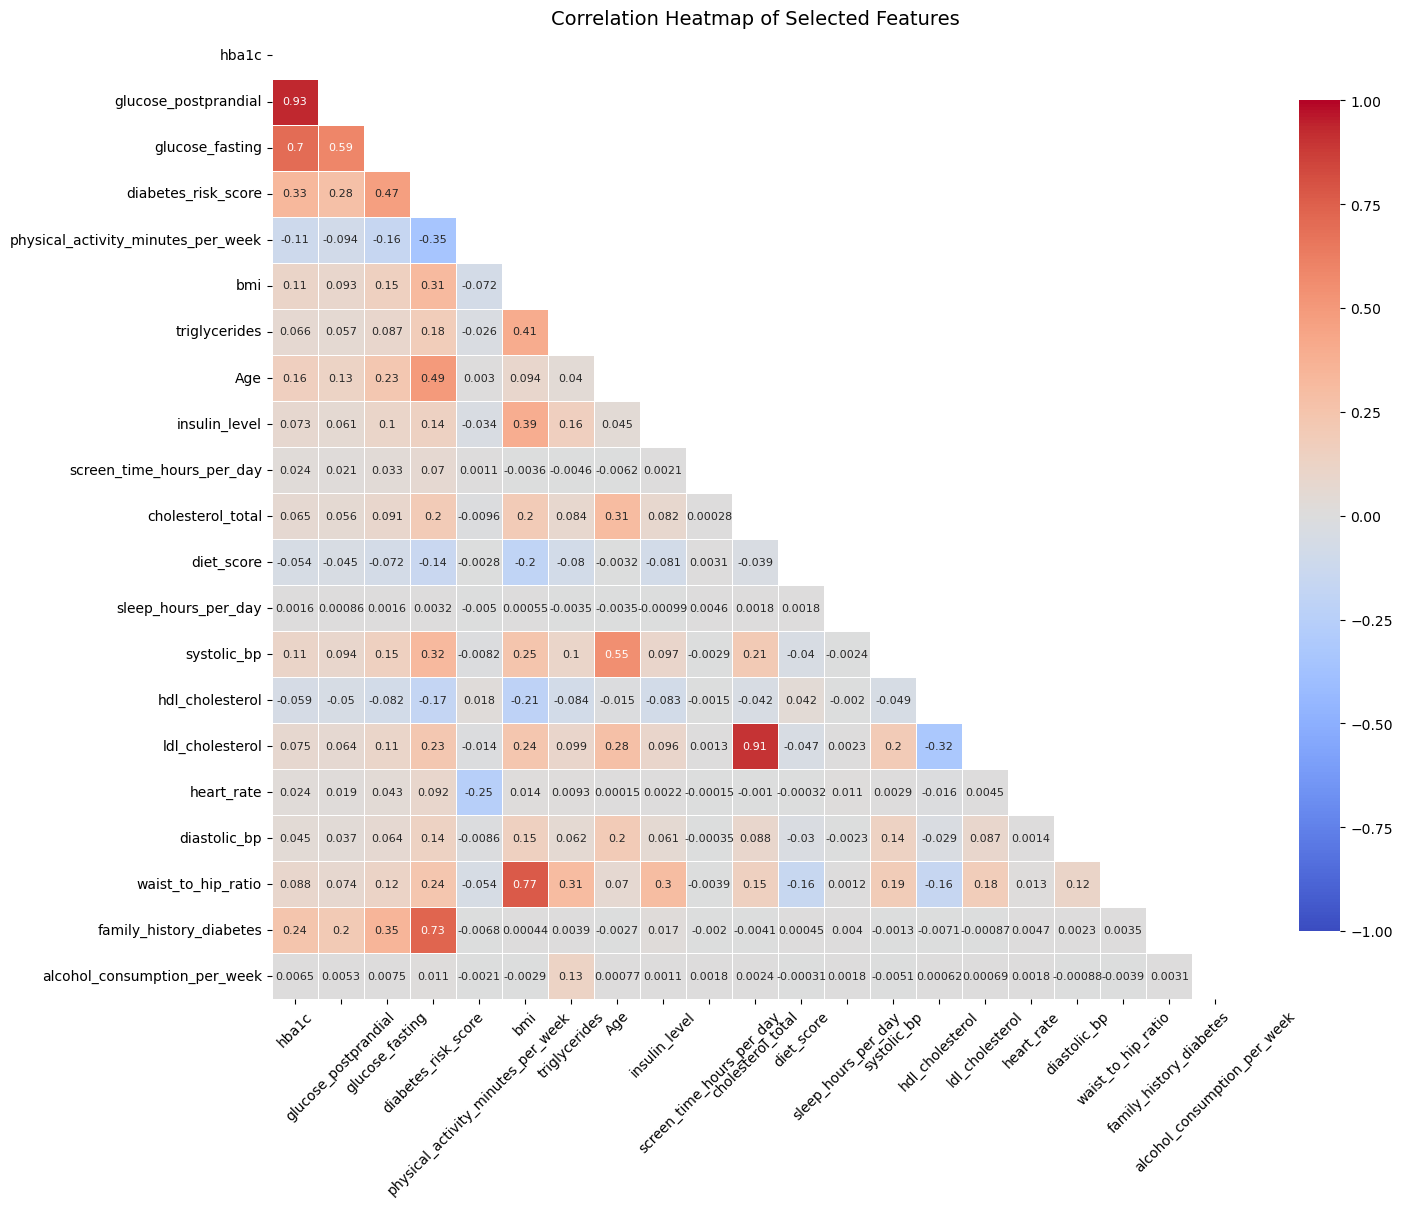

In [64]:
mask = np.triu(np.ones_like(X_selected.corr(), dtype=bool))

fig, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(
    X_selected.corr(),
    square=True,
    linewidths=0.5,
    cmap='coolwarm',
    cbar_kws={'shrink': 0.6},
    vmin=-1,
    vmax=1,
    annot=True,
    annot_kws={'size': 8},   # smaller text
    mask=mask,
    ax=ax
)

plt.title("Correlation Heatmap of Selected Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [65]:
##################################################
# KEY-INSIGHTS
##################################################
#The data preparation process involved cleaning the dataset, encoding categorical variables into numerical form, and handling outliers using capping techniques. 
#After this process, no extreme outliers were observed, indicating that the data distribution had been effectively controlled. 
#As a result, the dataset is now well-structured and ready for the model selection phase.

# K-Means Segmentation

#### Selecting features for Segmentation
##### Removing target column/variable, only want to use lifestyle and health features

In [68]:
# Selecting features for clustering
X_cluster = df.drop("diabetes_stage",axis=1)

X_cluster.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,239,41,160,145,136,236,6.36,8.18,29.6,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,116,55,50,30,93,150,2.00,5.63,23.0,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,213,66,99,36,118,195,5.07,7.51,44.7,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,171,50,79,140,139,253,5.28,9.03,38.2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,210,52,125,160,137,184,12.74,7.20,23.5,1


In [72]:
# Convert text into numbers to avoid errors
X_cluster_encoded = pd.get_dummies(X_cluster, drop_first=True)
X_cluster_encoded.head()

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,education_level_Postgraduate,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Former,smoking_status_Never
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,False,False,True,False,False,False,False,False,False,True
1,52,1,143,6.7,6.5,8.7,0,0,0,23.1,...,False,False,False,True,False,False,False,False,True,False
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,False,False,False,True,False,False,False,True,False,True
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,False,True,False,False,False,True,False,False,False,True
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,False,False,False,True,False,True,False,False,False,True


In [74]:
# Scaling, adjusting the data so that it is compatible.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster_encoded)

In [75]:
# Creating k-means, a clustering algorithm, to group similar data points
#Created 3 patient groups.
kmeans = KMeans(
    n_clusters =3,
    random_state=42)
kmeans.fit(X_scaled)

# Adding the cluster labe;s to the dataset
df["Cluster"] = kmeans.labels_
df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,Cluster
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,160,145,136,236,6.36,8.18,29.6,Type 2,1,2
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,1
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,99,36,118,195,5.07,7.51,44.7,Type 2,1,2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,79,140,139,253,5.28,9.03,38.2,Type 2,1,2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,125,160,137,184,12.74,7.20,23.5,Type 2,1,2


In [76]:
# CHecking the cluster size - shows how many patients are in each patient group
df["Cluster"].value_counts()

Cluster
2    39279
1    30976
0    27042
Name: count, dtype: int64

In [78]:
# Analysing the cluster characteristics- this group out data and also calculate the average values of each group
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
Cluster,,,,,,,,,,,,,,,,,,,,,
0,51.982028,2.017232,125.910325,5.864522,6.997996,5.899046,0.099882,0.267214,0.081688,26.892249,...,197.170365,52.571260,115.220768,129.813771,102.789698,134.585460,9.949200,5.821765,29.397367,0.140337
1,41.355759,1.976207,132.733762,6.399283,6.997698,5.988872,0.123128,0.188598,0.051330,22.872036,...,165.109052,57.527376,79.761654,102.706612,105.861796,152.930139,7.013416,6.299007,23.693928,0.509685
2,55.929759,2.018152,103.270399,5.766534,6.997518,6.070923,0.378243,0.288831,0.099137,26.899038,...,194.745513,52.309733,112.913363,130.513837,121.006212,183.107818,10.070683,7.175822,35.937929,0.987780


In [ ]:
# Interpreting clusters:

# cluster 0: Low Risk group
# Older age group but with a normal BMI
# Moderate physical activity and a moderate diet
# Glucose levels are within normal range
# Recommendation: Maintain the health living habits with annual diabetes monitoring
# cluster 1: Moderate Risk group
# Has the youngest age group with the lowest BMI
# Is the most active group with the best diet
# Glucose numbers show pre-diabetes numbers
# Recommendation: Increase activity and improve diet with regular diabetes screening for possible early intervention
# cluster 2: High Risk group
# Has the highest age and elevated glucose numbers that are well above diabetes thresholds, with the lowest physical activity and even poorer diet. This is a high risk cluster
# recommendation: Glucose control and intense lifestyle intervention(implementing a strict diet and exercise regiment)

In [79]:
# compare Cluster vs Diabetes Stage
pd.crosstab(df["Cluster"], df["diabetes_stage"])

diabetes_stage,Gestational,No Diabetes,Pre-Diabetes,Type 1,Type 2
Cluster,,,,,
0,42,4688,18501,26,3785
1,151,3049,12032,70,15674
2,74,0,480,21,38704


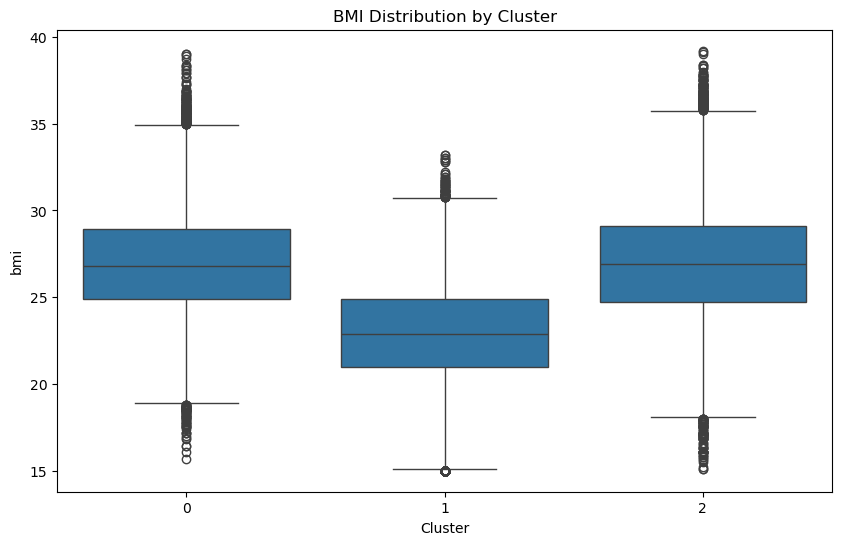

In [82]:
# Visualising the clusters - Using box plots
plt.figure()
# BMI boxplot
sns.boxplot(x="Cluster", y="bmi", data=df)
plt.title("BMI Distribution by Cluster")

plt.show()

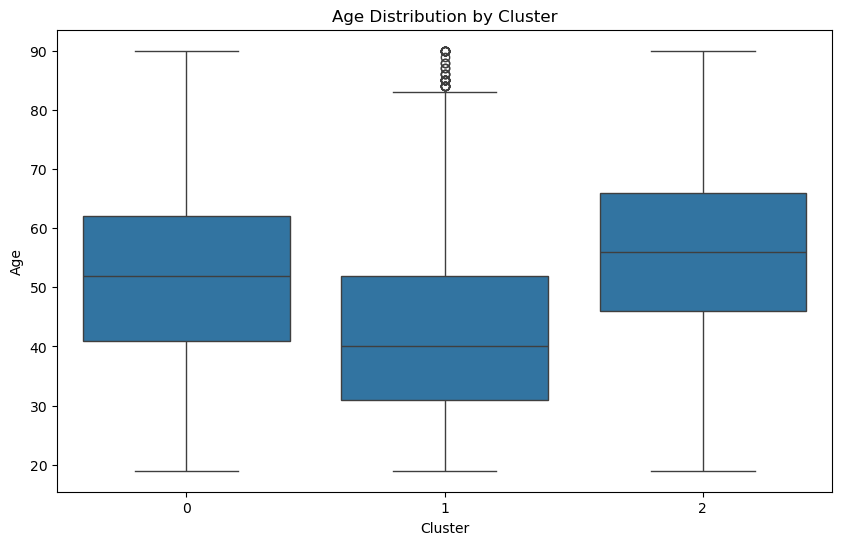

In [83]:
# Age boxplot
plt.figure()
sns.boxplot(x="Cluster", y="Age", data=df)
plt.title("Age Distribution by Cluster")

plt.show()

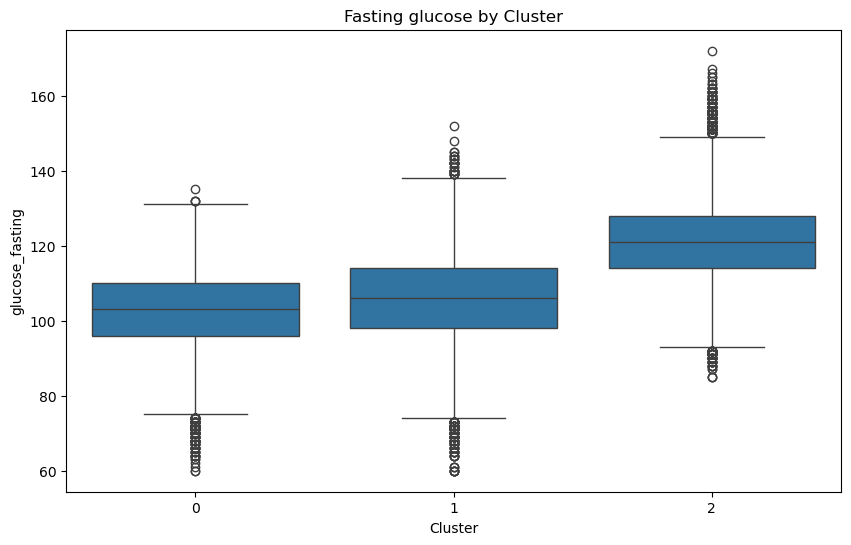

In [84]:
# Glucose boxplot
plt.figure()
sns.boxplot(x="Cluster", y="glucose_fasting", data=df)
plt.title("Fasting glucose by Cluster")

plt.show()

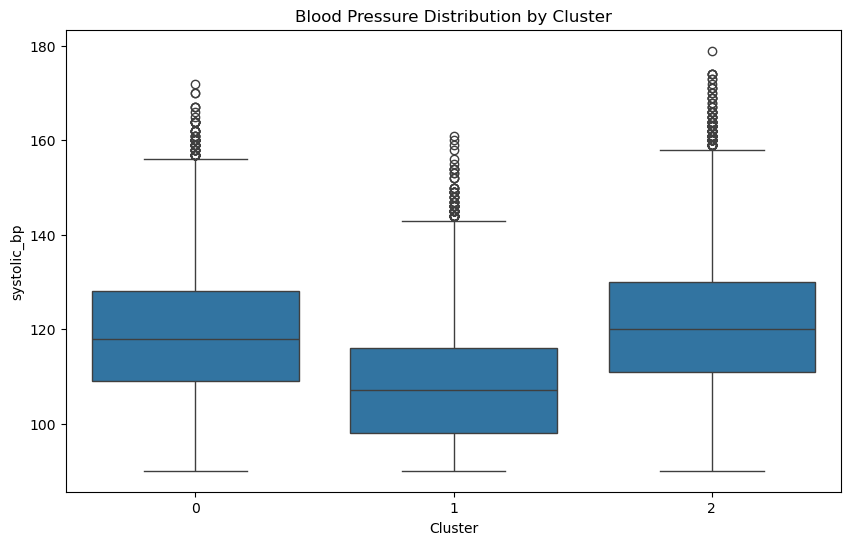

In [85]:
# Blood Pressure
plt.figure()
sns.boxplot(x="Cluster", y="systolic_bp", data=df)
plt.title("Blood Pressure Distribution by Cluster")

plt.show()


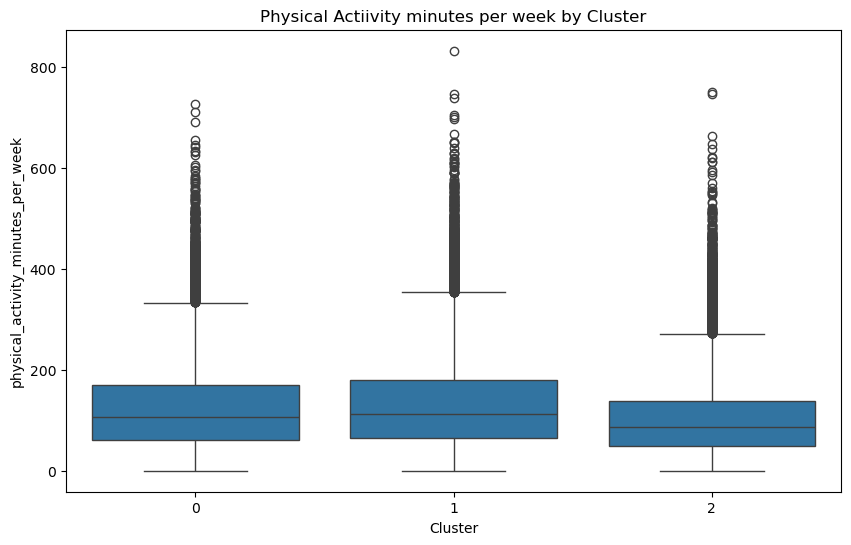

In [87]:
# physical Activity
plt.figure()
sns.boxplot(x="Cluster", y="physical_activity_minutes_per_week", data=df)
plt.title("Physical Actiivity minutes per week by Cluster")

plt.show()